Navpreet Kloy, Angel Vasquez

In [ ]:
#import required libaries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
# reads and stores csv file
df=pd.read_csv('day.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
# Displays number of missing (NaN) values in each column
print(df.isnull().sum())
#(rows, columns) in dataframe
print(df.shape)

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
(731, 16)


In [ ]:
df.nunique() #check number of unique values in each feature

,0
instant,731
dteday,731
season,4
yr,2
mnth,12
holiday,2
weekday,7
workingday,2
weathersit,3
temp,499


In [ ]:
# print unique values for selected columns
for col in df.columns[2:9]:
    print(col)
    print(df[col].unique())
    print()

season
[1 2 3 4]

yr
[0 1]

mnth
[ 1  2  3  4  5  6  7  8  9 10 11 12]

holiday
[0 1]

weekday
[6 0 1 2 3 4 5]

workingday
[0 1]

weathersit
[2 1 3]



In [ ]:
# check datatypes for all columns in dataframe
df.dtypes


,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64
temp,float64


In [ ]:
# compute correlation of all numeric features with 'cnt' and sort from highest to lowest
print(df.corr(numeric_only=True)['cnt']
      .sort_values(ascending=False))

cnt           1.000000
registered    0.945517
casual        0.672804
atemp         0.631066
instant       0.628830
temp          0.627494
yr            0.566710
season        0.406100
mnth          0.279977
weekday       0.067443
workingday    0.061156
holiday      -0.068348
hum          -0.100659
windspeed    -0.234545
weathersit   -0.297391
Name: cnt, dtype: float64


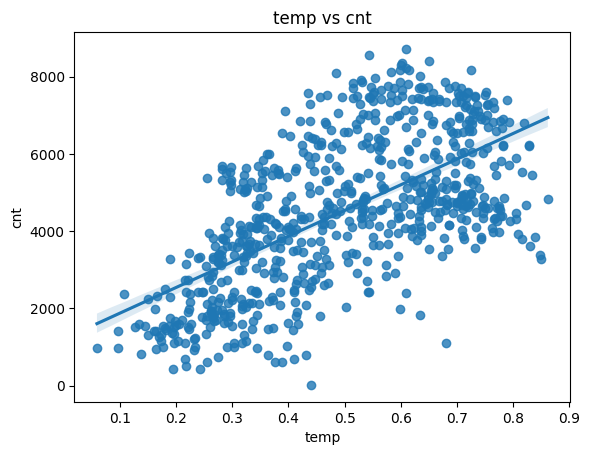

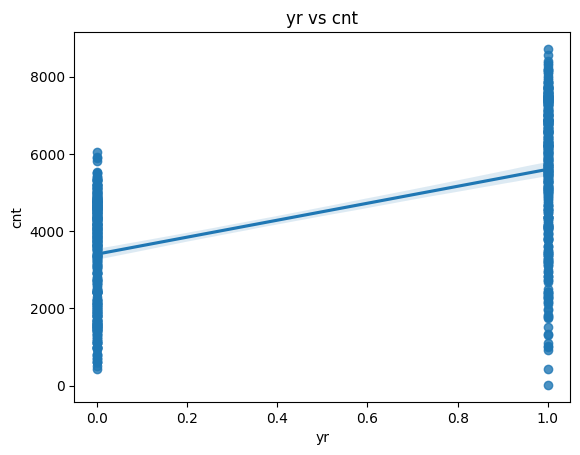

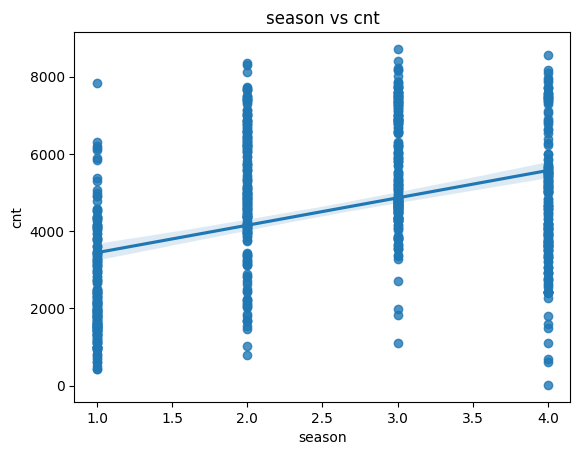

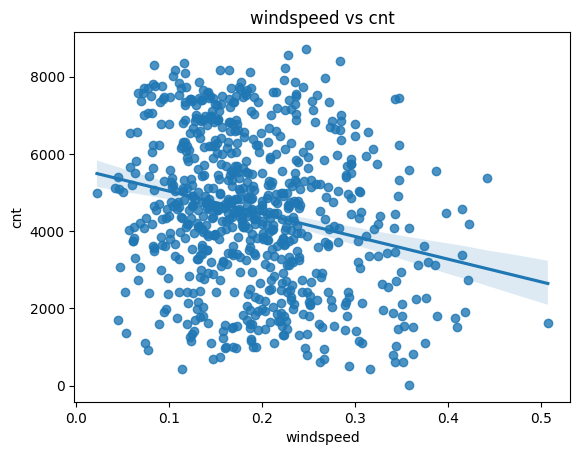

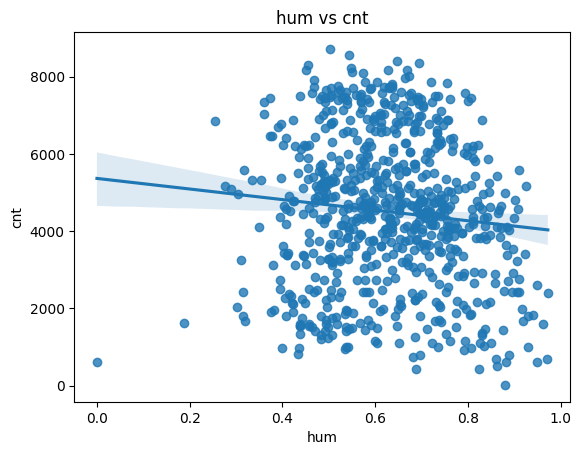

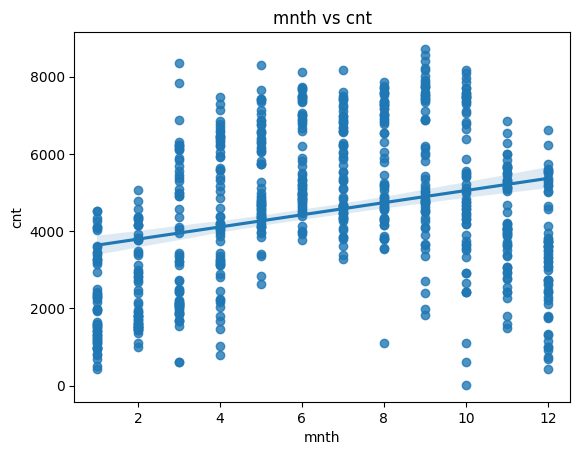

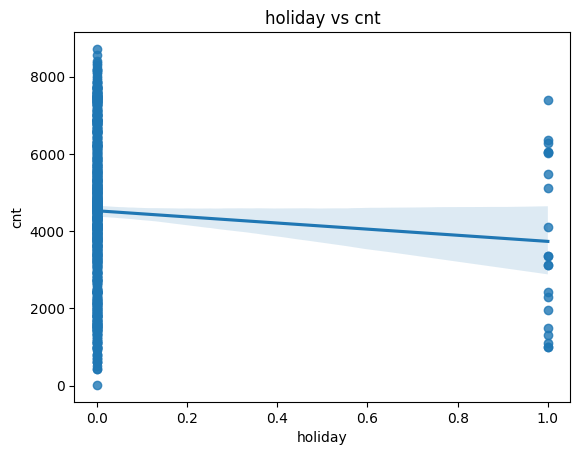

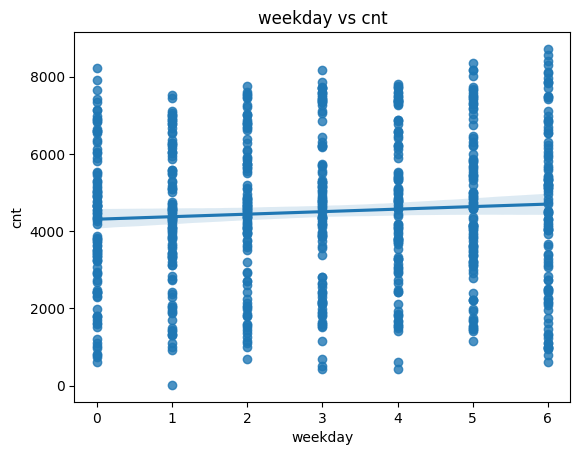

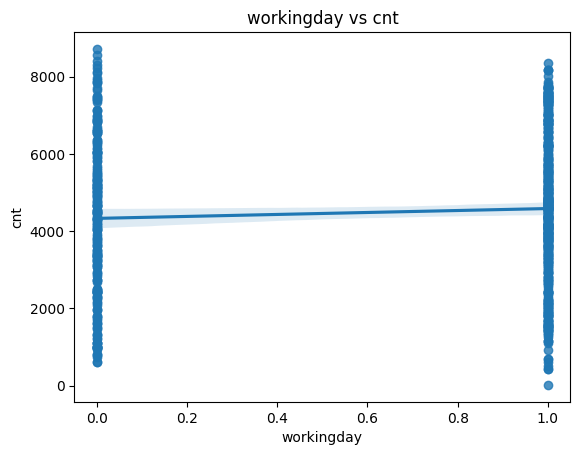

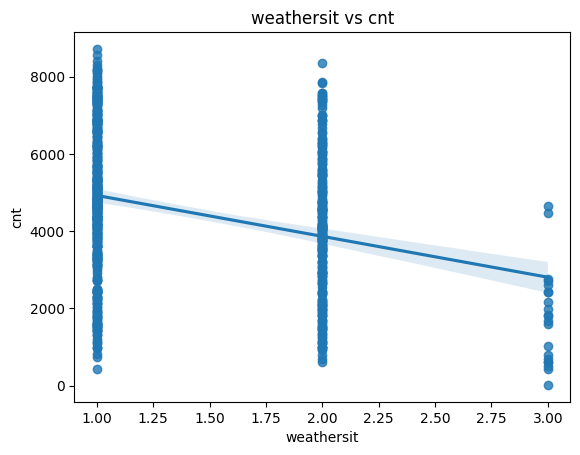

In [ ]:
# plot scatterplot with regression lines of selected features against 'cnt'
features = df[[ 'temp', 'yr', 'season', 'windspeed','hum','mnth','holiday','weekday','workingday','weathersit']]
for col in features:
    sns.regplot(x=col, y='cnt', data=df)
    plt.title(f'{col} vs cnt')
    plt.show()


In [ ]:
# one-hot encode selected categorical features
df = pd.get_dummies(df, columns=['season', 'weathersit', 'mnth','weekday'], drop_first=True)

In [ ]:
# Define features (x) and target (y)
x = df.drop(columns=['instant', 'dteday', 'casual', 'registered', 'cnt'])
y = df['cnt']

In [ ]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# Let's do a regression analysis
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train a linear regression model
model = LinearRegression()
model.fit(x_train, y_train)

# Make predictions on the test set
y_pred = model.predict(x_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 634351.361524895
R-squared: 0.8418029967286178


Text(0.5, 1.0, 'Actual vs. Predicted Daily Bike Rentals')

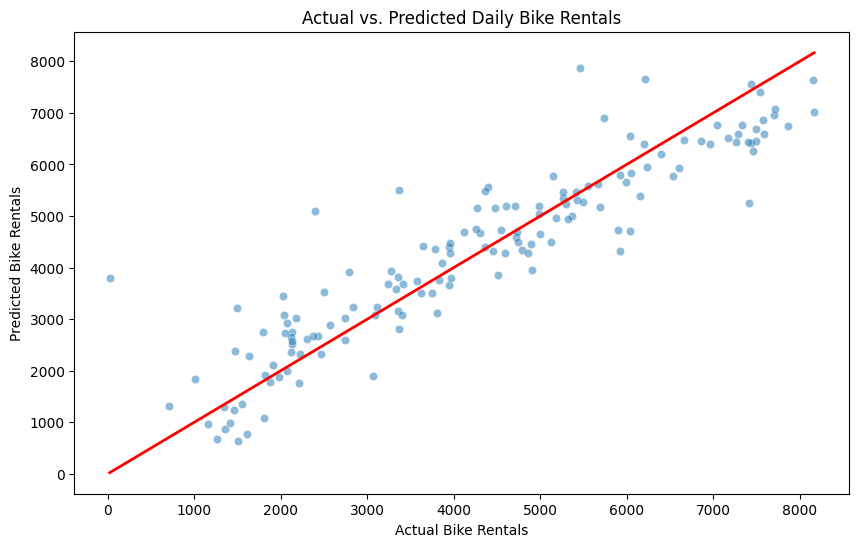

In [ ]:
# plot scatterplot for actual vs. predicted daily bike rentals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Bike Rentals')
plt.ylabel('Predicted Bike Rentals')
plt.title('Actual vs. Predicted Daily Bike Rentals')

In [ ]:
# prediction based on user input
while True:
        try:
            # take user input
            temp = float(input("Enter temperature in Celsius: "))
            yr = int(input("Enter 0 for 2011 year or 1 for 2012 year: "))
            season = int(input("Enter season (1-4): 1:winter, 2:spring, 3:summer, 4:fall"))
            month = int(input("Enter month (1-12):"))
            holiday = int(input("Enter holiday: 0 for holiday or 1 "))
            weekday = int(input("Enter weekday from 0-6:"))
            if weekday in [0, 6] or holiday == 1:
               workingday = 0
            else:
               workingday = 1
            weathersit = int(input("""Choose 1-3 for how weather is:
                1: Clear, Few clouds, Partly cloudy, Partly cloudy
		            2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
		            3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
		            ")) """))
            windspeed = float(input("Enter value for windspeed: "))
            hum = float(input("Enter humidity percentage: "))

            # normalize that data to match model scale
            temp = (temp + 8) / 47
            windspeed = windspeed / 67
            hum = hum / 100

            # Create user user input dataframe
            user_df = pd.DataFrame([{
                "temp": temp, "yr": yr, "season": season, "windspeed": windspeed, "hum": hum,
                "mnth": month, "holiday": holiday, "weekday": weekday, "workingday": workingday,
                "weathersit": weathersit
            }])

            user_df = pd.get_dummies(
                user_df,
                columns=["season", "weathersit", "mnth", "weekday"],
                drop_first=True
            )

            user_df = user_df.reindex(columns=x.columns, fill_value=0)


            # Make prediction
            predicted_number_of_rented_bikes = model.predict(user_df)[0]

            print(f"Predicted number of bikes rented for the day is: {predicted_number_of_rented_bikes:.2f}")
            break  # Exit the loop if input is valid

        except ValueError:
            print("Invalid input. Please enter valid input.")
        except Exception as e:
          print(f"An error occurred: {e}")
          print("Please restart and enter the correct values.")
          break
while True:
    another_prediction = input("Do you want to predict another prediction? (yes/no): ")
    if another_prediction.lower() != 'yes':
        break


Enter temperature in Celsius: 23
Enter 0 for 2011 year or 1 for 2012 year: 1
Enter season (1-4): 1:winter, 2:spring, 3:summer, 4:fall1
Enter month (1-12):2
Enter holiday: 0 for holiday or 1 1
Enter weekday from 0-6:1
Choose 1-3 for how weather is:
                1: Clear, Few clouds, Partly cloudy, Partly cloudy
		            2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
		            3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
		            ")) 1
Enter value for windspeed: 1
Enter humidity percentage: 10
Predicted number of bikes rented for the day is: 5390.97
Do you want to predict another prediction? (yes/no): no
